# SF$_6$-like - calculate observational network global- annual-mean, latitudinal gradient and seasonality

Calculate global-mean, latitudinal gradient and seasonality
based on the observational network.
We also perform an EOF analysis for the latitudinal gradient.
We also perform an EOF analysis for the seasonality change.

## Imports

In [1]:
from pathlib import Path

import cf_xarray.units
import matplotlib.axes
import matplotlib.pyplot as plt
import pint_xarray
import xarray as xr
from pydoit_nb.config_handling import get_config_for_step_id

import local.binned_data_interpolation
import local.binning
import local.latitudinal_gradient
import local.mean_preserving_interpolation
import local.raw_data_processing
import local.seasonality
import local.xarray_space
import local.xarray_time
from local.config import load_config_from_file

In [2]:
cf_xarray.units.units.define("ppm = 1 / 1000000")
cf_xarray.units.units.define("ppb = ppm / 1000")
cf_xarray.units.units.define("ppt = ppb / 1000")

pint_xarray.accessors.default_registry = pint_xarray.setup_registry(cf_xarray.units.units)

## Define branch this notebook belongs to

In [3]:
step: str = "calculate_sf6_like_monthly_fifteen_degree_pieces"

## Parameters

In [4]:
config_file: str = "../../dev-config-absolute.yaml"  # config file
step_config_id: str = "ch2cl2"  # config ID to select for this branch

In [5]:
# Parameters
config_file = "/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/v1.0.0-config.yaml"
step_config_id = "cf4"


## Load config

In [6]:
config = load_config_from_file(Path(config_file))
config_step = get_config_for_step_id(config=config, step=step, step_config_id=step_config_id)

## Action

### Load data

In [7]:
interpolated_spatial: xr.DataArray = xr.load_dataarray(  # type: ignore
    config_step.observational_network_interpolated_file
).pint.quantify()
interpolated_spatial

Magnitude,[[[74.568 74.568 74.568 ... 75.544 75.544 75.544] [74.568 74.568 74.568 ... 75.544 75.544 75.544] [74.568 74.568 74.568 ... 75.544 75.544 75.544] [74.568 74.568 74.568 ... 75.544 75.544 75.544] [74.568 74.568 74.568 ... 75.544 75.544 75.544] [74.568 74.568 74.568 ... 75.544 75.544 75.544]] [[74.656 74.656 74.656 ... 75.499 75.499 75.499] [74.656 74.656 74.656 ... 75.499 75.499 75.499] [74.656 74.656 74.656 ... 75.499 75.499 75.499] [74.656 74.656 74.656 ... 75.499 75.499 75.499] [74.656 74.656 74.656 ... 75.499 75.499 75.499] [74.656 74.656 74.656 ... 75.499 75.499 75.499]] [[74.611 74.611 74.611 ... 75.363 75.363 75.363] [74.611 74.611 74.611 ... 75.363 75.363 75.363] [74.611 74.611 74.611 ... 75.363 75.363 75.363] [74.611 74.611 74.611 ... 75.363 75.363 75.363] [74.611 74.611 74.611 ... 75.363 75.363 75.363] [74.611 74.611 74.611 ... 75.363 75.363 75.363]] ... [[89.102 89.102 89.102 ... 90.15233333333335 90.03366666666668 89.915] [89.102 89.102 89.102 ... 90.15233333333333 90.03366666666666 89.915] [89.102 89.102 89.102 ... 90.222 90.03366666666666 89.915] [89.102 89.102 89.102 ... 90.0275 89.97125 89.915] [89.102 89.102 89.102 ... 90.08991666666667 90.03366666666668 89.915] [89.102 89.102 89.102 ... 90.15233333333333 90.03366666666668 89.915]] [[89.231 89.231 89.231 ... 90.28133333333334 90.19066666666666 90.1] [89.231 89.231 89.231 ... 90.28133333333332 90.19066666666666 90.1] [89.231 89.231 89.231 ... 90.39 90.19066666666666 90.1] [89.231 89.231 89.231 ... 90.303 90.2015 90.1] [89.231 89.231 89.231 ... 90.29216666666667 90.19066666666666 90.1] [89.231 89.231 89.231 ... 90.28133333333334 90.19066666666666 90.1]] [[89.32 89.32 89.32 ... 90.404 90.391 90.378] [89.32 89.32 89.32 ... 90.404 90.391 90.378] [89.32 89.32 89.32 ... 90.29374999999999 90.39099999999999 90.378] [89.32 89.32 89.32 ... 90.3425 90.36025000000001 90.378] [89.32 89.32 89.32 ... 90.37325000000001 90.391 90.378] [89.32 89.32 89.32 ... 90.404 90.391 90.378]]]
Units,ppt


In [8]:
if config_step.year_drop_observational_data_before_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        > config_step.year_drop_observational_data_before_and_including
    )

if config_step.year_drop_observational_data_after_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        < config_step.year_drop_observational_data_after_and_including
    )

interpolated_spatial

Magnitude,[[[76.36 76.36 76.36 ... 77.299 77.299 77.299] [76.36 76.36 76.36 ... 77.299 77.299 77.299] [76.36 76.36 76.36 ... 77.299 77.299 77.299] [76.36 76.36 76.36 ... 77.299 77.299 77.299] [76.36 76.36 76.36 ... 77.299 77.299 77.299] [76.36 76.36 76.36 ... 77.299 77.299 77.299]] [[76.381 76.381 76.381 ... 77.365 77.365 77.365] [76.381 76.381 76.381 ... 77.365 77.365 77.365] [76.381 76.381 76.381 ... 77.365 77.365 77.365] [76.381 76.381 76.381 ... 77.365 77.365 77.365] [76.381 76.381 76.381 ... 77.365 77.365 77.365] [76.381 76.381 76.381 ... 77.365 77.365 77.365]] [[76.398 76.398 76.398 ... 77.449 77.449 77.449] [76.398 76.398 76.398 ... 77.449 77.449 77.449] [76.398 76.398 76.398 ... 77.449 77.449 77.449] [76.398 76.398 76.398 ... 77.449 77.449 77.449] [76.398 76.398 76.398 ... 77.449 77.449 77.449] [76.398 76.398 76.398 ... 77.449 77.449 77.449]] ... [[89.102 89.102 89.102 ... 90.15233333333335 90.03366666666668 89.915] [89.102 89.102 89.102 ... 90.15233333333333 90.03366666666666 89.915] [89.102 89.102 89.102 ... 90.222 90.03366666666666 89.915] [89.102 89.102 89.102 ... 90.0275 89.97125 89.915] [89.102 89.102 89.102 ... 90.08991666666667 90.03366666666668 89.915] [89.102 89.102 89.102 ... 90.15233333333333 90.03366666666668 89.915]] [[89.231 89.231 89.231 ... 90.28133333333334 90.19066666666666 90.1] [89.231 89.231 89.231 ... 90.28133333333332 90.19066666666666 90.1] [89.231 89.231 89.231 ... 90.39 90.19066666666666 90.1] [89.231 89.231 89.231 ... 90.303 90.2015 90.1] [89.231 89.231 89.231 ... 90.29216666666667 90.19066666666666 90.1] [89.231 89.231 89.231 ... 90.28133333333334 90.19066666666666 90.1]] [[89.32 89.32 89.32 ... 90.404 90.391 90.378] [89.32 89.32 89.32 ... 90.404 90.391 90.378] [89.32 89.32 89.32 ... 90.29374999999999 90.39099999999999 90.378] [89.32 89.32 89.32 ... 90.3425 90.36025000000001 90.378] [89.32 89.32 89.32 ... 90.37325000000001 90.391 90.378] [89.32 89.32 89.32 ... 90.404 90.391 90.378]]]
Units,ppt


### Drop out any years that have nan

These break everything later on

In [9]:
interpolated_spatial_no_year_with_nan = local.xarray_time.convert_time_to_year_month(
    interpolated_spatial
).dropna("year")
if interpolated_spatial_no_year_with_nan["year"].shape[0] != (
    interpolated_spatial_no_year_with_nan["year"].max()
    - interpolated_spatial_no_year_with_nan["year"].min()
    + 1
):
    msg = f"Missing years, this will not end well {interpolated_spatial_no_year_with_nan['year'].values=}"
    raise AssertionError(msg)

interpolated_spatial_no_year_with_nan

<xarray.DataArray 'cf4' (lon: 6, lat: 12, year: 16, month: 12)> Size: 111kB
<Quantity([[[[76.36       76.381      76.398      ... 76.851      76.839
    76.906     ]
   [76.912      77.093      77.153      ... 77.465      77.577
    77.548     ]
   [77.557      77.712      77.885      ... 78.035      78.052
    78.156     ]
   ...
   [85.779      85.94275    86.14133333 ... 86.66       86.833
    86.65825   ]
   [87.551      87.502      87.677      ... 88.499      88.553
    88.28      ]
   [88.358      88.482      88.523      ... 89.102      89.231
    89.32      ]]

  [[76.36       76.381      76.398      ... 76.851      76.839
    76.906     ]
   [76.912      77.093      77.153      ... 77.465      77.577
    77.548     ]
   [77.557      77.712      77.885      ... 78.035      78.052
    78.156     ]
...
   [87.19708333 87.40442857 87.48225    ... 87.96394444 88.28316667
    88.358     ]
   [88.4755     88.72233333 88.86133333 ... 89.25733333 89.473
    89.507     ]
   [89.666      89.73933333 89.83       ... 90.03366667 90.19066667
    90.391     ]]

  [[77.299      77.365      77.449      ... 77.87       77.963
    77.998     ]
   [77.961      77.918      77.989      ... 78.201      78.321
    78.38      ]
   [78.431      78.501      78.568      ... 78.931      79.038
    79.089     ]
   ...
   [87.33633333 87.46875    87.4555     ... 88.04816667 88.2435
    88.36325   ]
   [88.58       88.72       88.86       ... 89.201      89.507
    89.502     ]
   [89.662      89.748      89.818      ... 89.915      90.1
    90.378     ]]]], 'ppt')>
Coordinates:
  * year     (year) int64 128B 2008 2009 2010 2011 2012 ... 2020 2021 2022 2023
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 96B -82.5 -67.5 -52.5 -37.5 ... 37.5 52.5 67.5 82.5
  * lon      (lon) float64 48B -150.0 -90.0 -30.0 30.0 90.0 150.0
Attributes:
    description:  Interpolated spatial data

In [10]:
interpolated_spatial_nan_free = local.xarray_time.convert_year_month_to_time(
    interpolated_spatial_no_year_with_nan
)
interpolated_spatial_nan_free

Magnitude,[[[76.36 76.381 76.398 ... 89.102 89.231 89.32] [76.36 76.381 76.398 ... 89.102 89.231 89.32] [76.36 76.381 76.398 ... 89.102 89.231 89.32] ... [77.299 77.365 77.449 ... 90.15233333333335 90.28133333333334 90.404] [77.299 77.365 77.449 ... 90.03366666666668 90.19066666666666 90.391] [77.299 77.365 77.449 ... 89.915 90.1 90.378]] [[76.36 76.381 76.398 ... 89.102 89.231 89.32] [76.36 76.381 76.398 ... 89.102 89.231 89.32] [76.36 76.381 76.398 ... 89.102 89.231 89.32] ... [77.299 77.365 77.449 ... 90.15233333333333 90.28133333333332 90.404] [77.299 77.365 77.449 ... 90.03366666666666 90.19066666666666 90.391] [77.299 77.365 77.449 ... 89.915 90.1 90.378]] [[76.36 76.381 76.398 ... 89.102 89.231 89.32] [76.36 76.381 76.398 ... 89.102 89.231 89.32] [76.36 76.381 76.398 ... 89.102 89.231 89.32] ... [77.299 77.365 77.449 ... 90.222 90.39 90.29374999999999] [77.299 77.365 77.449 ... 90.03366666666666 90.19066666666666 90.39099999999999] [77.299 77.365 77.449 ... 89.915 90.1 90.378]] [[76.36 76.381 76.398 ... 89.102 89.231 89.32] [76.36 76.381 76.398 ... 89.102 89.231 89.32] [76.36 76.381 76.398 ... 89.102 89.231 89.32] ... [77.299 77.365 77.449 ... 90.0275 90.303 90.3425] [77.299 77.365 77.449 ... 89.97125 90.2015 90.36025000000001] [77.299 77.365 77.449 ... 89.915 90.1 90.378]] [[76.36 76.381 76.398 ... 89.102 89.231 89.32] [76.36 76.381 76.398 ... 89.102 89.231 89.32] [76.36 76.381 76.398 ... 89.102 89.231 89.32] ... [77.299 77.365 77.449 ... 90.08991666666667 90.29216666666667 90.37325000000001] [77.299 77.365 77.449 ... 90.03366666666668 90.19066666666666 90.391] [77.299 77.365 77.449 ... 89.915 90.1 90.378]] [[76.36 76.381 76.398 ... 89.102 89.231 89.32] [76.36 76.381 76.398 ... 89.102 89.231 89.32] [76.36 76.381 76.398 ... 89.102 89.231 89.32] ... [77.299 77.365 77.449 ... 90.15233333333333 90.28133333333334 90.404] [77.299 77.365 77.449 ... 90.03366666666668 90.19066666666666 90.391] [77.299 77.365 77.449 ... 89.915 90.1 90.378]]]
Units,ppt


### Longitudinal-mean

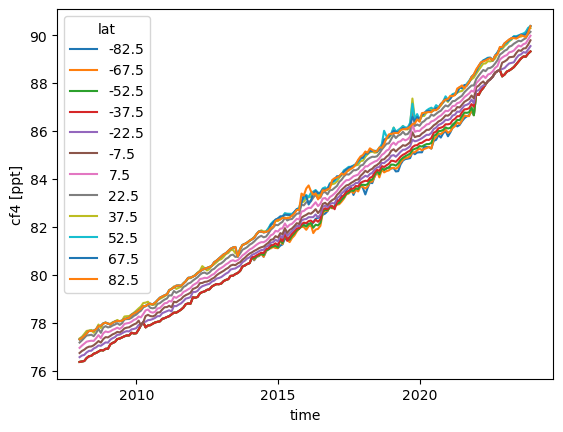

In [11]:
lon_mean = interpolated_spatial_nan_free.mean(dim="lon")
lon_mean.plot(hue="lat")  # type: ignore

### Global-, annual-mean

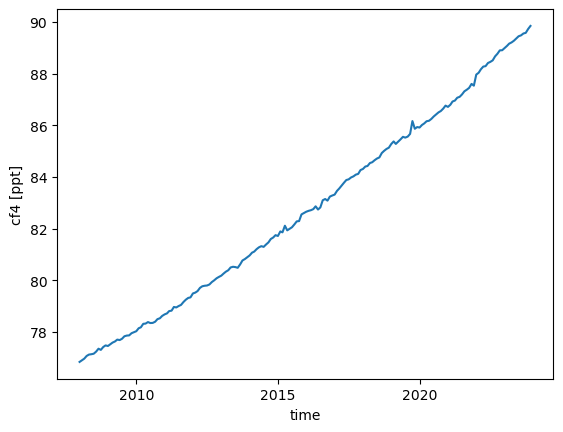

In [12]:
global_mean = local.xarray_space.calculate_global_mean_from_lon_mean(lon_mean)
global_mean.plot()  # type: ignore

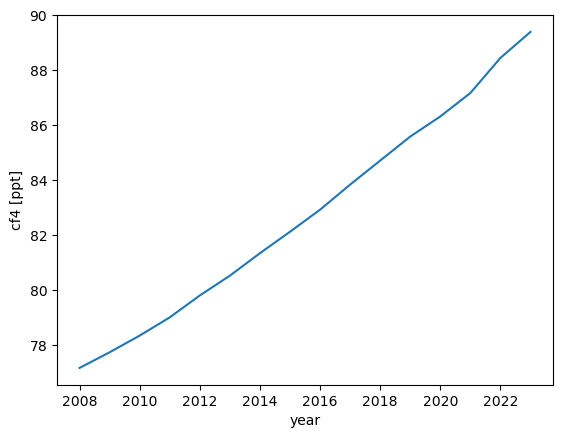

In [13]:
global_annual_mean = global_mean.groupby("time.year").mean()
global_annual_mean.plot()  # type: ignore

### Latitudinal gradient

In [14]:
(
    lat_residuals_annual_mean,
    lat_gradient_full_eofs_pcs,
) = local.latitudinal_gradient.calculate_eofs_pcs(lon_mean, global_mean)
lat_gradient_full_eofs_pcs

<xarray.Dataset> Size: 3kB
Dimensions:               (lat: 12, eof: 12, year: 16)
Coordinates:
  * lat                   (lat) float64 96B -82.5 -67.5 -52.5 ... 52.5 67.5 82.5
  * eof                   (eof) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * year                  (year) int64 128B 2008 2009 2010 ... 2021 2022 2023
Data variables:
    eofs                  (lat, eof) float64 1kB [ppt] 0.3635 -0.63 ... -0.05329
    principal-components  (year, eof) float64 2kB [] -1.534 ... -2.742e-15

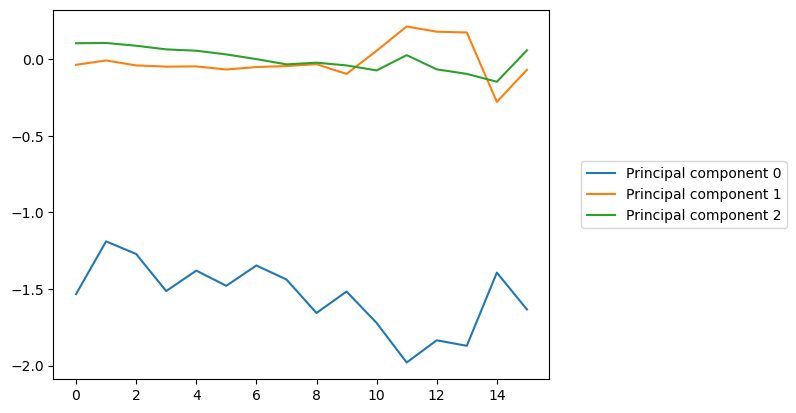

In [15]:
fig, ax = plt.subplots()
n_eofs_to_show = 3

for i in range(n_eofs_to_show):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).data.m,
        label=f"Principal component {i}",
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

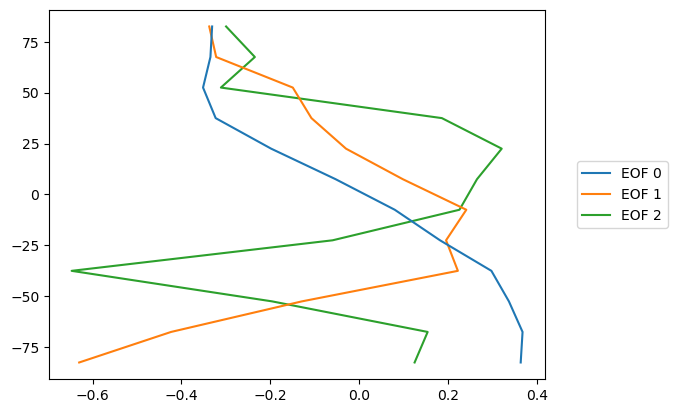

In [16]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["eofs"].sel(eof=i).data.m,
        lat_gradient_full_eofs_pcs["lat"].data,
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

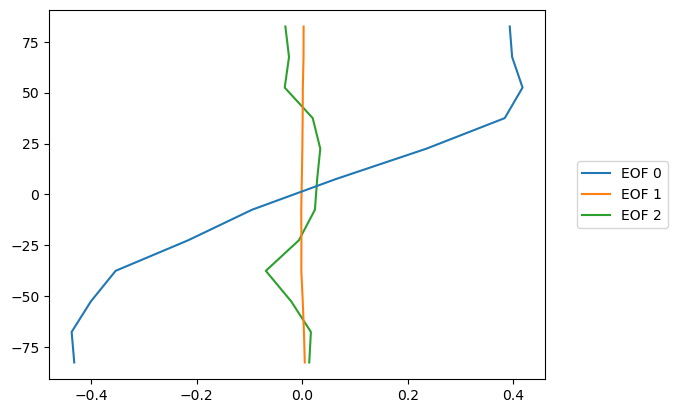

In [17]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).isel(year=1)
        @ lat_gradient_full_eofs_pcs["eofs"].sel(eof=i),
        lat_gradient_full_eofs_pcs["lat"],
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

In [18]:
lat_gradient_eofs_pcs = lat_gradient_full_eofs_pcs.sel(eof=range(config_step.lat_gradient_n_eofs_to_use))
lat_gradient_eofs_pcs

Magnitude,[[0.36347684896263904] [0.3676342832285296] [0.3369460386571406] [0.297554437019566] [0.181912128573207] [0.08007178766523554] [-0.05296216186919808] [-0.19807285590537307] [-0.32287946068439455] [-0.3512839568662129] [-0.3346726989234856] [-0.3308467888313218]]
Units,ppt
Magnitude,[[-1.5337838230117515] [-1.1892615925588266] [-1.271450339971709] [-1.5135921070768132] [-1.3799341536147858] [-1.479289638199638] [-1.3466843753095434] [-1.4377987499665776] [-1.6567405394287482] [-1.51671046014256] [-1.7219445446969621] [-1.980011075704485] [-1.83502326821654] [-1.8711041151265264] [-1.392972863668689] [-1.6337570868065285]]
Units,dimensionless


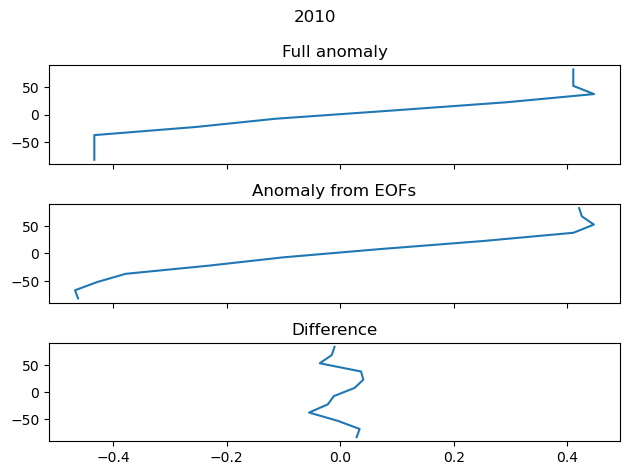

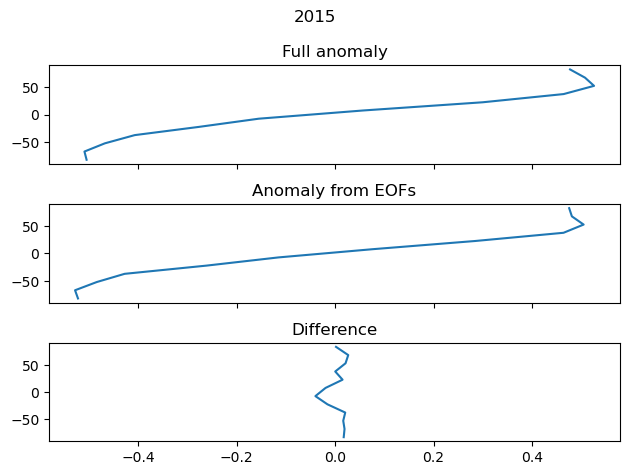

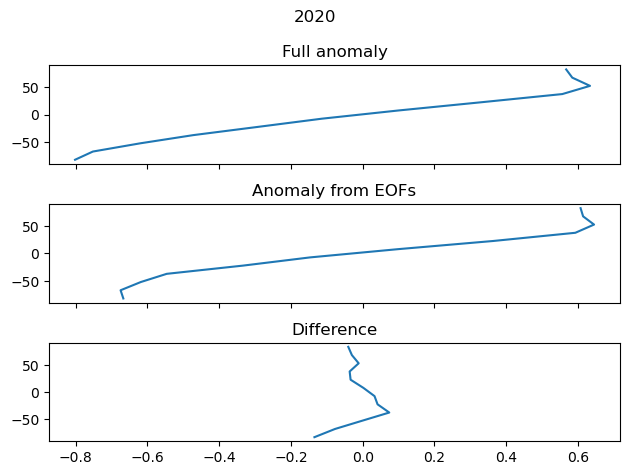

In [19]:
latitudinal_anomaly_from_eofs = lat_gradient_eofs_pcs["principal-components"] @ lat_gradient_eofs_pcs["eofs"]

for year in latitudinal_anomaly_from_eofs["year"]:
    if year % 5:
        continue

    fig, axes = plt.subplots(nrows=3, sharex=True, sharey=True)
    if isinstance(axes, matplotlib.axes.Axes):
        raise TypeError(type(axes))

    selected = lat_residuals_annual_mean.sel(year=year)
    axes[0].plot(selected.data.m, lat_residuals_annual_mean.lat)
    axes[0].set_title("Full anomaly")

    selected_eofs = latitudinal_anomaly_from_eofs.sel(year=year)
    axes[1].plot(selected_eofs.data.m, latitudinal_anomaly_from_eofs.lat)
    axes[1].set_title("Anomaly from EOFs")

    axes[2].plot(selected.data.m - selected_eofs.data.m, lat_residuals_annual_mean.lat)
    axes[2].set_title("Difference")

    axes[0].set_ylim([-90, 90])

    plt.suptitle(str(int(year)))
    plt.tight_layout()
    plt.show()

### Seasonality

In [20]:
(
    seasonality,
    relative_seasonality,
    lon_mean_ym_monthly_anomalies,
) = local.seasonality.calculate_seasonality(
    lon_mean=lon_mean,
    global_mean=global_mean,
)

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore
/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/.pixi/envs/all-dev/lib/python3.11/importlib/__init__.py:126: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  return _bootstrap._gcd_import(name[level:], package, level)


Calculating output values:   0%|                                                                                                                                                                                      | 0/192 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 192/192 [00:00<00:00, 18231.98it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/192 [00:00<?, ?it/s]

...

Calculating output values:   0%|                                                                                                                                                                                      | 0/192 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 192/192 [00:00<00:00, 17764.63it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/192 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 192/192 [00:00<00:00, 19516.43it/s]

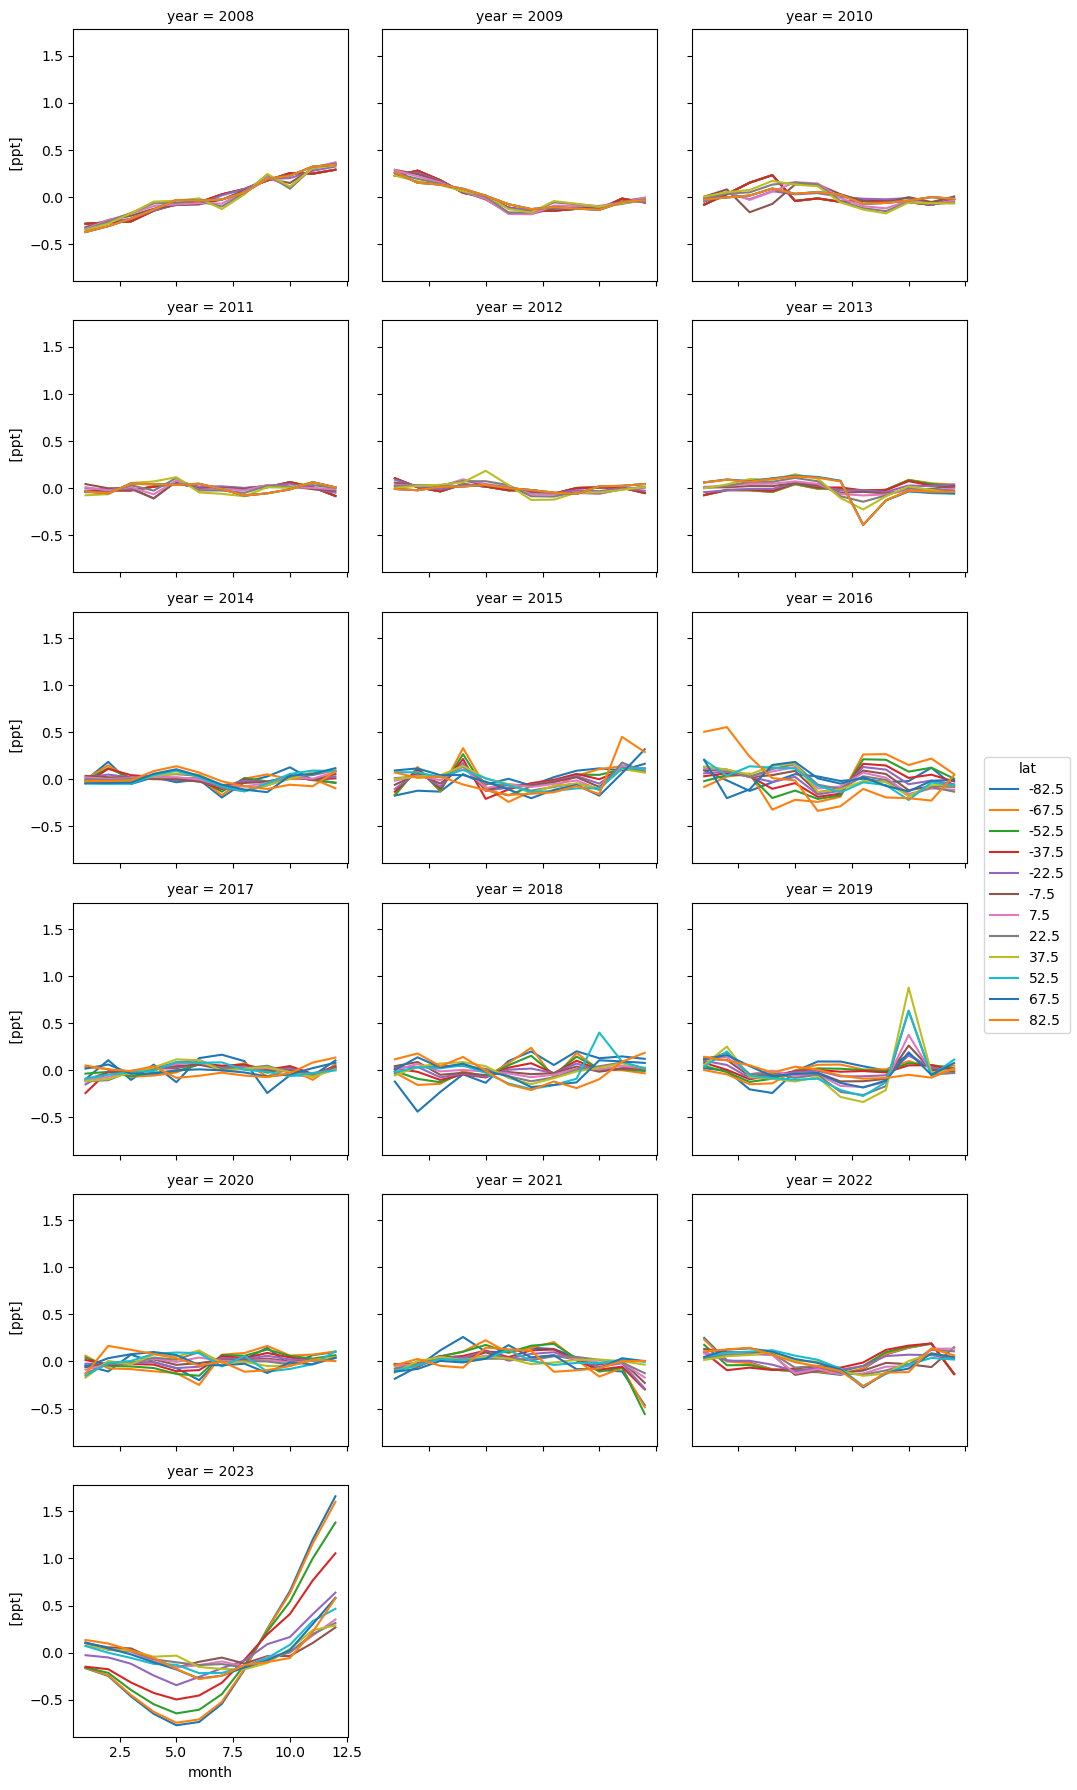

In [21]:
lon_mean_ym_monthly_anomalies.plot.line(hue="lat", col="year", col_wrap=3)

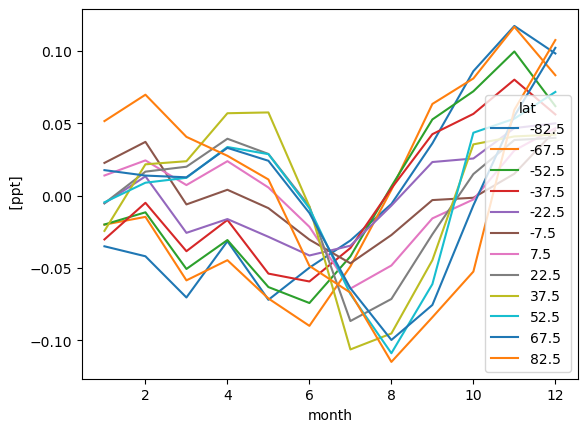

In [22]:
seasonality.plot.line(hue="lat")

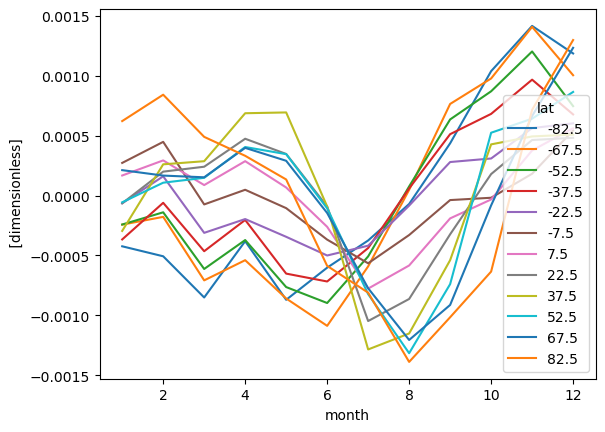

In [23]:
relative_seasonality.plot.line(hue="lat")

### Save

In [24]:
config_step.observational_network_global_annual_mean_file.parent.mkdir(exist_ok=True, parents=True)
global_annual_mean.pint.dequantify().to_netcdf(config_step.observational_network_global_annual_mean_file)
global_annual_mean

Magnitude,[77.17042094990889 77.73992434373365 78.34647437279212 79.00862112327454 79.80617118377084 80.52614313538322 81.3436211037797 82.1229707630721 82.92596261150622 83.8387825830925 84.71172094148262 85.58634837143666 86.3170049147683 87.16965611332398 88.44613532893736 89.39176084213398]
Units,ppt


In [25]:
config_step.observational_network_latitudinal_gradient_eofs_file.parent.mkdir(exist_ok=True, parents=True)
lat_gradient_eofs_pcs.pint.dequantify().to_netcdf(
    config_step.observational_network_latitudinal_gradient_eofs_file
)
lat_gradient_eofs_pcs

Magnitude,[[0.36347684896263904] [0.3676342832285296] [0.3369460386571406] [0.297554437019566] [0.181912128573207] [0.08007178766523554] [-0.05296216186919808] [-0.19807285590537307] [-0.32287946068439455] [-0.3512839568662129] [-0.3346726989234856] [-0.3308467888313218]]
Units,ppt
Magnitude,[[-1.5337838230117515] [-1.1892615925588266] [-1.271450339971709] [-1.5135921070768132] [-1.3799341536147858] [-1.479289638199638] [-1.3466843753095434] [-1.4377987499665776] [-1.6567405394287482] [-1.51671046014256] [-1.7219445446969621] [-1.980011075704485] [-1.83502326821654] [-1.8711041151265264] [-1.392972863668689] [-1.6337570868065285]]
Units,dimensionless


In [26]:
# Use relative seasonality
config_step.observational_network_seasonality_file.parent.mkdir(exist_ok=True, parents=True)
relative_seasonality.pint.dequantify().to_netcdf(config_step.observational_network_seasonality_file)
relative_seasonality

Magnitude,[[-0.00042351642860883747 -0.0005069419546388628 -0.0008510789990479559 -0.00038096609659607993 -0.0008704418825192508 -0.0006020526149627796 -0.0003748816770558504 -7.008238967130473e-05 0.00043652256201399053 0.0010392359010578146 0.0014171469269141995 0.0011870850543918875] [-0.00024271707655048577 -0.00017766589054685067 -0.0007081086094835625 -0.0005396320662155446 -0.0008593863851202723 -0.0010879237441512818 -0.0005911917015260979 4.816117541622413e-05 0.0007654154434126653 0.0009782879970764763 0.0014093740090704938 0.0010054139144636783] [-0.0002416114610808913 -0.00013962377328534243 -0.0006128806807824969 -0.0003714111143673527 -0.0007639971394212272 -0.0008972476773167335 -0.0005079604547164194 7.654403618367871e-05 0.0006360744427114775 0.0008712086917117961 0.0012037571109775212 0.0007471701285702587] [-0.00036624416607792057 -6.0338637483175376e-05 -0.0004645360176784037 -0.00020342496315118268 -0.0006516296995509031 -0.0007174284164325915 -0.000438034752513108 6.002162763869232e-05 0.0005129736034359478 0.0006824386744349441 0.0009682885752234814 0.0006779289201215105] [-6.416059516436099e-05 0.00016093120564322362 -0.0003112108930922796 -0.00019601468761452258 -0.0003442744279620055 -0.0005003963534086658 -0.00041853754937965426 -8.368219897359058e-05 0.0002803150901119067 0.0003098153802787279 0.0005638434602251572 0.0006033772075251466] [0.00027294902519791556 0.00044872179342292964 -7.382314526677596e-05 4.860722666757632e-05 -0.00010488266838781062 -0.0003678910945171396 -0.0005655093651580878 -0.00032937407340934616 -3.746143346198116e-05 -1.8089947693849888e-05 0.00018233904769475857 0.0005444116387590265] [0.00016779166780237748 0.0002939374981457893 8.781176440454018e-05 0.00028750412047581 6.759804648937147e-05 -0.0002608511894779294 -0.0007768549903593736 -0.000583767999178976 -0.00019045906938336117 -3.2388297877259557e-05 0.0003769482839651438 0.000562729352078582] [-6.438476433001276e-05 0.00020001899697094452 0.00024112012461450407 0.00047482135199197176 0.000347773840176917 -9.1123528060729e-05 -0.0010477611128576546 -0.0008635115737415464 -0.0003233244453448355 0.00017975217879012456 0.00046417698436589637 0.0004824415879895864] [-0.00029515668692889954 0.00026115329343160906 0.00028717864639673764 0.0006878884108129433 0.0006945365787330067 -9.121959399210918e-05 -0.0012850641009247382 -0.001151693357872107 -0.0005393626945293927 0.0004277880727697428 0.0004941754974342154 0.0005097762529593638] [-5.6171033135954655e-05 0.0001076479082840607 0.00014851179641503146 0.00040570663700565724 0.000346114931470165 -0.0001062471853024587 -0.0008227025937257277 -0.0013164745363728493 -0.0007394960345896125 0.0005249691719334363 0.0006423605254616271 0.0008657840590697666] [0.0002125692854818571 0.00016716057572773325 0.00015277877918157436 0.0003985275674322635 0.000290732640990807 -0.00014533769832423171 -0.0007740499725351383 -0.0012059450920189085 -0.0009134701334451115 -8.189946174701104e-05 0.0006646472115396675 0.0012342917606797518] [0.0006223006642792458 0.0008426435580916876 0.0004904258261652479 0.00033227376431310327 0.00013461632963865968 -0.00058712975298735 -0.0008107066122945345 -0.0013892802614550032 -0.001016293632189605 -0.0006347616297799896 0.0007166648118768021 0.001299251583998116]]
Units,dimensionless
